In [10]:
#Baseline model
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.utils.data import Subset

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1) Loading the dataset that has been processed during the Data Processing steps**

In [2]:
#Upload to Google Drive the split_dataset.zip

!unzip /content/drive/MyDrive/Colab_Notebooks/Project/split_dataset.zip -d /content/


Streaming output truncated to the last 5000 lines.
  inflating: /content/split_dataset/val/no_action/0012718/frame_009.jpg  
  inflating: /content/split_dataset/val/no_action/0012718/frame_008.jpg  
   creating: /content/split_dataset/val/no_action/0022710/
  inflating: /content/split_dataset/val/no_action/0022710/frame_003.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_002.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_000.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_014.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_015.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_001.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_005.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_011.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_010.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_004.jpg  
  

In [3]:
#Paths
DATA_DIR = "/content/split_dataset"
weights_path = os.path.join(DATA_DIR, "class_weights.json")

**2) Load the class weights and create the weights tensor**

In [4]:
#Load class weights in Colab that I have been saved in class_weights.json
import json

weights_path = "/content/split_dataset/class_weights.json"
with open(weights_path, "r") as f:
    data = json.load(f)

class_counts = data['class_counts']
class_weights = data['class_weights']

print(class_counts)
print(class_weights)


{'walk': 187984, 'pass': 17120, 'ball in hand': 37792, 'defense': 61856, 'run': 94784, 'shoot': 6816, 'dribble': 55840, 'pick': 11392, 'block': 15936, 'no_action': 103840}
{'walk': 0.3156, 'pass': 3.4659, 'ball in hand': 1.5701, 'defense': 0.9593, 'run': 0.626, 'shoot': 8.7054, 'dribble': 1.0626, 'pick': 5.2086, 'block': 3.7234, 'no_action': 0.5714}


In [5]:
# Create weights tensor for PyTorch CrossEntropyLoss
labels = list(class_counts.keys())

weights_list = []
for label in labels:
    weights_list.append(class_weights[label])
weights_tensor = torch.tensor(weights_list, dtype=torch.float)

# Map label name -> index
label_map = {}
for i in range(len(labels)):
    label = labels[i]
    label_map[label] = i
print(label_map)

{'walk': 0, 'pass': 1, 'ball in hand': 2, 'defense': 3, 'run': 4, 'shoot': 5, 'dribble': 6, 'pick': 7, 'block': 8, 'no_action': 9}


**3) Initialize the frame dataset so it can be processed as a tensor**

In [6]:
#Dataset class
class FrameDataset(Dataset):
    def __init__(self, root_dir, label_map, transform=None):
        """
        Initialize the frame dataset.

        Args:
            root_dir: Root directory containing label folders
            label_map: Dictionary mapping label names to integer indices
            transform: Optional image transformations to apply
        """
        self.samples = [] # List to store (frame_path, label_index) tuples
        self.transform = transform

        # Iterate through each label directory
        for label in os.listdir(root_dir):
            label_path = os.path.join(root_dir, label)
            #Skip if not directory
            if not os.path.isdir(label_path):
                continue
            # Iterate through each video folder within the label directory
            for video in os.listdir(label_path):
                video_path = os.path.join(label_path, video)
                # Get all frame paths from this video
                frames = [os.path.join(video_path, f) for f in os.listdir(video_path)]
                # Add each frame as a separate sample with its corresponding label index
                for frame_path in frames:  # Each frame is treated independently
                    self.samples.append((frame_path, label_map[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Get a single frame and its label.

        Args:
            idx: Index of the sample to retrieve

        Returns:
            image: Flattened grayscale image tensor
            label: Integer label index
        """
        # Get the frame path and label for this index
        frame_path, label = self.samples[idx]
        # Load image and convert to grayscale ('L' mode)
        image = Image.open(frame_path).convert('L')
        # Apply transformations such as resizing and normalize
        if self.transform:
            image = self.transform(image)
        # Flatten the image 3D image into 1D vector
        image = torch.flatten(image)
        return image, label


#Transforms: resize and normalize frames
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # resize to reduce input size
    transforms.ToTensor(),        # convert to [0,1] tensor
])

**4) Set the seed for reproducibility and fair comparison between models**

In [8]:
import random

SEED = 100  # or any number you like
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

**5) Create the DataLoaders for the training, validation and testing data**

In [13]:
#Create dataset
train_dataset = FrameDataset(os.path.join(DATA_DIR, "train"), label_map, transform)
val_dataset   = FrameDataset(os.path.join(DATA_DIR, "val"), label_map, transform)
test_dataset  = FrameDataset(os.path.join(DATA_DIR, "test"), label_map, transform)


#We have around 37000 videos with 15 frames/videos so around 555000 images total
#This create a huge dataset, so we went to limit it by subsample the dataset
def subsample_by_class(dataset, ratio=0.1):
    class_indices = {}
    for idx, (_, label) in enumerate(dataset.samples):  # no image loading
        class_indices.setdefault(label, []).append(idx)

    selected_indices = []
    for label, indices in class_indices.items():
        n_keep = max(1, int(len(indices) * ratio))
        sampled = random.sample(indices, n_keep)
        selected_indices.extend(sampled)

    np.random.shuffle(selected_indices)
    return Subset(dataset, selected_indices)

# Apply 10% per class
train_dataset = subsample_by_class(train_dataset, 0.1)
val_dataset   = subsample_by_class(val_dataset, 0.1)
test_dataset  = subsample_by_class(test_dataset, 0.1)



# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)


In [15]:
#To verify the sample sizes per class after subsampling
from collections import Counter

# Extract the labels (second element of each sample) for the subset
labels_in_subset = [
    train_dataset.dataset.samples[i][1] for i in train_dataset.indices
]

# Count how many samples per label index
print(Counter(labels_in_subset))

Counter({0: 15038, 9: 8307, 4: 7582, 3: 4947, 6: 4467, 2: 3022, 1: 1369, 8: 1273, 7: 910, 5: 544})


**6) 1st model : Simple ANN**

In [16]:
#Define the ANN
class SimpleANN(nn.Module):
    def __init__(self, input_size, hidden1=512, hidden2=256, num_classes=len(label_map)):
        super(SimpleANN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

In [17]:
# Get input size
sample_img, _ = train_dataset[0]
input_size = sample_img.numel()  # flattened size

model = SimpleANN(input_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define Loss and optimizer
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3)

**7) Create an evaluation function to get the accuracy and average loss of the model**

In [31]:
# Validation function (returns accuracy and loss)
def evaluate(model, dataloader, device, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for images, labels_batch in dataloader:
            images, labels_batch = images.to(device), labels_batch.to(device, dtype=torch.long)
            outputs = model(images)
            loss = criterion(outputs, labels_batch)  # now uses the passed criterion
            total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return accuracy, avg_loss

**8) Training of the Simple ANN using the class weights**

Using device: cuda
Epoch 1/5 | Train Loss: 2.2188 | Train Acc: 0.1879 | Val Loss: 2.2062 | Val Acc: 0.2179
Epoch 2/5 | Train Loss: 2.1830 | Train Acc: 0.1940 | Val Loss: 2.1894 | Val Acc: 0.1313
Epoch 3/5 | Train Loss: 2.1632 | Train Acc: 0.1926 | Val Loss: 2.1794 | Val Acc: 0.1597
Epoch 4/5 | Train Loss: 2.1375 | Train Acc: 0.1891 | Val Loss: 2.1633 | Val Acc: 0.1869
Epoch 5/5 | Train Loss: 2.1209 | Train Acc: 0.1862 | Val Loss: 2.1827 | Val Acc: 0.2124
✅ Training and validation tracking complete!


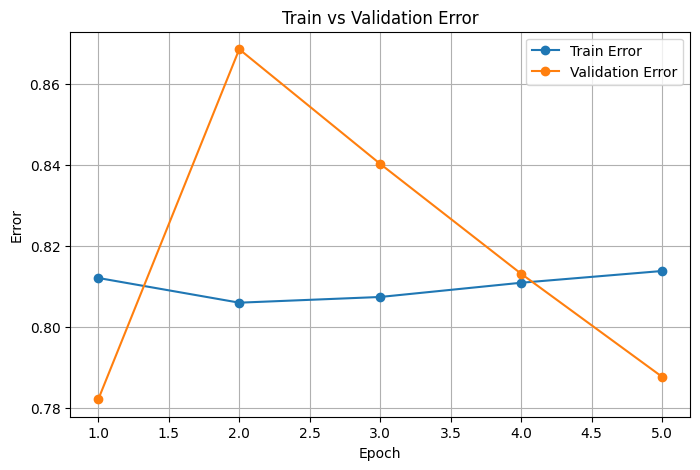

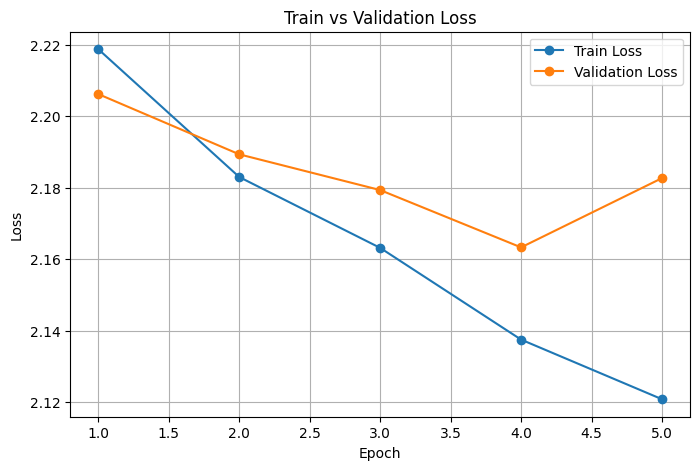

In [20]:
# --- Training loop with validation tracking ---
EPOCHS = 5
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print(f"Using device: {device}")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels_batch in train_loader:
        images, labels_batch = images.to(device), labels_batch.to(device, dtype=torch.long)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()

    # --- Compute train metrics ---
    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # --- Compute validation metrics ---
    val_acc, val_loss = evaluate(model, val_loader, device)

    # --- Store results ---
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print("✅ Training and validation tracking complete!")

# --- Plotting function ---
def plot_training_curves(train_acc, val_acc, train_loss, val_loss):
    epochs = np.arange(1, len(train_acc) + 1)

    # Error = 1 - accuracy
    train_err = [1 - acc for acc in train_acc]
    val_err = [1 - acc for acc in val_acc]

    plt.figure(figsize=(8,5))
    plt.title("Train vs Validation Error")
    plt.plot(epochs, train_err, label="Train Error", marker='o')
    plt.plot(epochs, val_err, label="Validation Error", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.title("Train vs Validation Loss")
    plt.plot(epochs, train_loss, label="Train Loss", marker='o')
    plt.plot(epochs, val_loss, label="Validation Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Plot results ---
plot_training_curves(train_accuracies, val_accuracies, train_losses, val_losses)


**9) 2nd model: Strong ANN (more hidden layers + features)**

In [21]:
class StrongANN(nn.Module):
    def __init__(self, input_size=64*64, num_classes=10):
        super(StrongANN, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)
        return x


In [23]:
# --- Initialize model, loss, and optimizer ---
num_classes = len(set([label for _, label in train_dataset]))
model = StrongANN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Using device: cuda
Epoch 1/10 | Train Loss: 1.8694 | Train Acc: 0.3231 | Val Loss: 1.8421 | Val Acc: 0.3403
Epoch 2/10 | Train Loss: 1.8266 | Train Acc: 0.3315 | Val Loss: 1.7987 | Val Acc: 0.3395
Epoch 3/10 | Train Loss: 1.7977 | Train Acc: 0.3372 | Val Loss: 1.7732 | Val Acc: 0.3511
Epoch 4/10 | Train Loss: 1.7792 | Train Acc: 0.3418 | Val Loss: 1.7462 | Val Acc: 0.3547
Epoch 5/10 | Train Loss: 1.7597 | Train Acc: 0.3457 | Val Loss: 1.7442 | Val Acc: 0.3536
Epoch 6/10 | Train Loss: 1.7470 | Train Acc: 0.3531 | Val Loss: 1.7205 | Val Acc: 0.3636
Epoch 7/10 | Train Loss: 1.7313 | Train Acc: 0.3566 | Val Loss: 1.7278 | Val Acc: 0.3481
Epoch 8/10 | Train Loss: 1.7203 | Train Acc: 0.3622 | Val Loss: 1.7094 | Val Acc: 0.3719
Epoch 9/10 | Train Loss: 1.7048 | Train Acc: 0.3696 | Val Loss: 1.7020 | Val Acc: 0.3798
Epoch 10/10 | Train Loss: 1.6920 | Train Acc: 0.3739 | Val Loss: 1.6859 | Val Acc: 0.3768
Training and validation complete


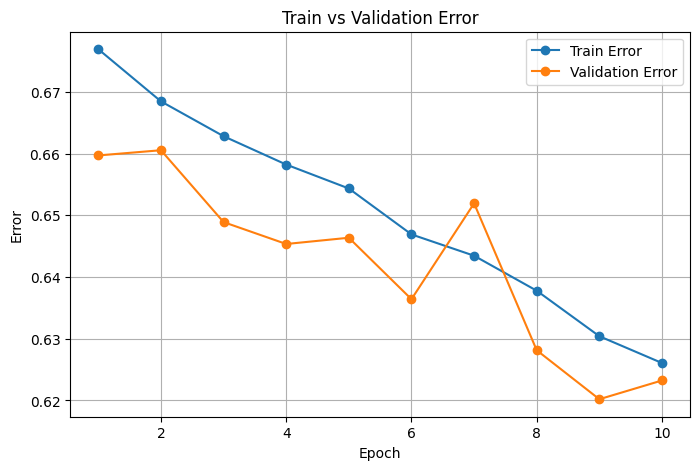

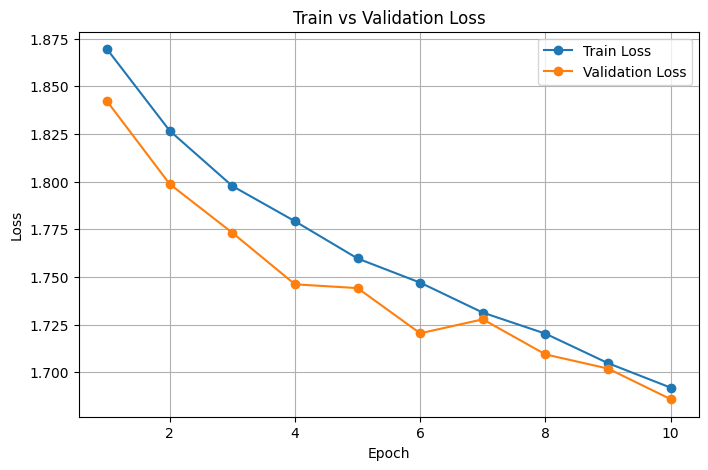

In [25]:
# --- Training loop with validation tracking ---
EPOCHS = 10
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print(f"Using device: {device}")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels_batch in train_loader:
        images, labels_batch = images.to(device), labels_batch.to(device, dtype=torch.long)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()

    # --- Compute train metrics ---
    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # --- Compute validation metrics ---
    val_acc, val_loss = evaluate(model, val_loader, device)

    # --- Store results ---
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print("Training and validation complete")

# --- Plotting function ---
def plot_training_curves(train_acc, val_acc, train_loss, val_loss):
    epochs = np.arange(1, len(train_acc) + 1)

    # Error = 1 - accuracy
    train_err = [1 - acc for acc in train_acc]
    val_err = [1 - acc for acc in val_acc]

    plt.figure(figsize=(8,5))
    plt.title("Train vs Validation Error")
    plt.plot(epochs, train_err, label="Train Error", marker='o')
    plt.plot(epochs, val_err, label="Validation Error", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.title("Train vs Validation Loss")
    plt.plot(epochs, train_loss, label="Train Loss", marker='o')
    plt.plot(epochs, val_loss, label="Validation Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Plot results ---
plot_training_curves(train_accuracies, val_accuracies, train_losses, val_losses)



**10) 3rd model: Large ANN (more features)**

In [50]:
#Let's try to increase the # Epoch + largerANN

class LargeANN(nn.Module):
    def __init__(self, input_size=64*64, num_classes=10):
        super(LargeANN, self).__init__()
        self.fc1 = nn.Linear(input_size, 2048)  # bigger first layer
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.fc4 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

**11) Create a training function to be reusable for future models**

In [51]:
#Train function
def train_model(net, train_loader, val_loader, device, total_epochs=20, lr=1e-4):

    # Move model to device
    net = net.to(device)

    print(f"Using device: {device}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)

    # Tracking metrics
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(total_epochs):
        net.train()
        total_loss = 0
        correct = 0
        total = 0

        for images, labels_batch in train_loader:
            images, labels_batch = images_batch = images.to(device), labels_batch.to(device, dtype=torch.long)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

        # Train metrics
        avg_train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Validation metrics
        val_acc, val_loss = evaluate(net, val_loader, device, criterion)

        # Store metrics
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{total_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    print("Training complete!")

    return net, train_losses, val_losses, train_accs, val_accs


In [76]:
num_classes = len(set([label for _, label in train_dataset]))

Using device: cuda
Epoch 1/20 | Train Loss: 1.8476 | Train Acc: 0.3292 | Val Loss: 1.8130 | Val Acc: 0.3417
Epoch 2/20 | Train Loss: 1.7941 | Train Acc: 0.3371 | Val Loss: 1.7721 | Val Acc: 0.3442
Epoch 3/20 | Train Loss: 1.7703 | Train Acc: 0.3410 | Val Loss: 1.8196 | Val Acc: 0.3454
Epoch 4/20 | Train Loss: 1.7477 | Train Acc: 0.3483 | Val Loss: 1.7392 | Val Acc: 0.3609
Epoch 5/20 | Train Loss: 1.7301 | Train Acc: 0.3557 | Val Loss: 1.7327 | Val Acc: 0.3577
Epoch 6/20 | Train Loss: 1.7117 | Train Acc: 0.3644 | Val Loss: 1.7210 | Val Acc: 0.3602
Epoch 7/20 | Train Loss: 1.6958 | Train Acc: 0.3700 | Val Loss: 1.7013 | Val Acc: 0.3763
Epoch 8/20 | Train Loss: 1.6756 | Train Acc: 0.3790 | Val Loss: 1.7129 | Val Acc: 0.3766
Epoch 9/20 | Train Loss: 1.6618 | Train Acc: 0.3836 | Val Loss: 1.7363 | Val Acc: 0.3611
Epoch 10/20 | Train Loss: 1.6484 | Train Acc: 0.3895 | Val Loss: 1.7042 | Val Acc: 0.3724
Epoch 11/20 | Train Loss: 1.6345 | Train Acc: 0.3925 | Val Loss: 1.6930 | Val Acc: 0.3803


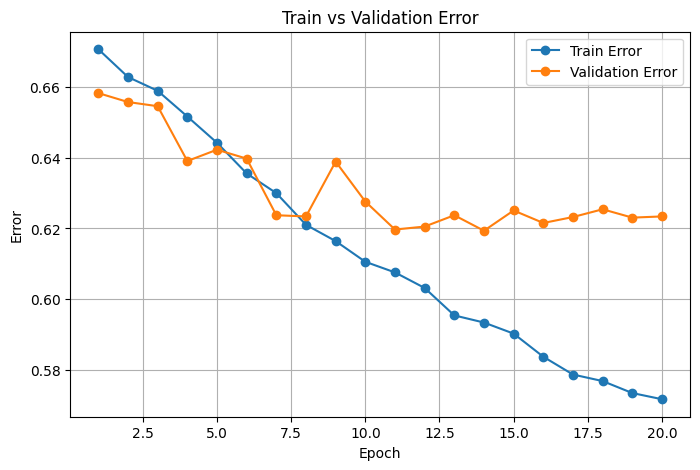

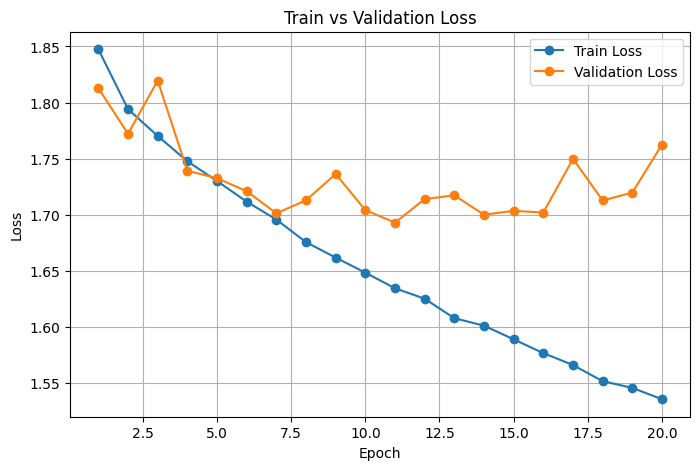

In [37]:
model = LargeANN(input_size=64*64, num_classes=num_classes).to(device)

model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, device, total_epochs=20, lr=1e-3
)

# Plot curves
plot_training_curves(train_accs, val_accs, train_losses, val_losses)

**12) 4th model: Large ANN (with dropout to prevent overfitting)**

In [52]:
class LargeANN(nn.Module):
    def __init__(self, input_size=64*64, num_classes=10, dropout_prob=0.0):
        super(LargeANN, self).__init__()
        self.fc1 = nn.Linear(input_size, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.bn2 = nn.BatchNorm1d(1024)
        self.fc3 = nn.Linear(1024, 512)
        self.bn3 = nn.BatchNorm1d(512)
        self.fc4 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

Using device: cuda
Epoch 1/20 | Train Loss: 1.8441 | Train Acc: 0.3295 | Val Loss: 1.8143 | Val Acc: 0.3403
Epoch 2/20 | Train Loss: 1.7973 | Train Acc: 0.3375 | Val Loss: 1.7842 | Val Acc: 0.3410
Epoch 3/20 | Train Loss: 1.7749 | Train Acc: 0.3388 | Val Loss: 1.7764 | Val Acc: 0.3454
Epoch 4/20 | Train Loss: 1.7508 | Train Acc: 0.3476 | Val Loss: 1.7429 | Val Acc: 0.3550
Epoch 5/20 | Train Loss: 1.7344 | Train Acc: 0.3513 | Val Loss: 1.7419 | Val Acc: 0.3548
Epoch 6/20 | Train Loss: 1.7178 | Train Acc: 0.3577 | Val Loss: 1.7782 | Val Acc: 0.3496
Epoch 7/20 | Train Loss: 1.7028 | Train Acc: 0.3635 | Val Loss: 1.7286 | Val Acc: 0.3557
Epoch 8/20 | Train Loss: 1.6905 | Train Acc: 0.3665 | Val Loss: 1.7154 | Val Acc: 0.3636
Epoch 9/20 | Train Loss: 1.6773 | Train Acc: 0.3729 | Val Loss: 1.7223 | Val Acc: 0.3650
Epoch 10/20 | Train Loss: 1.6652 | Train Acc: 0.3786 | Val Loss: 1.7208 | Val Acc: 0.3614
Epoch 11/20 | Train Loss: 1.6575 | Train Acc: 0.3831 | Val Loss: 1.7090 | Val Acc: 0.3690


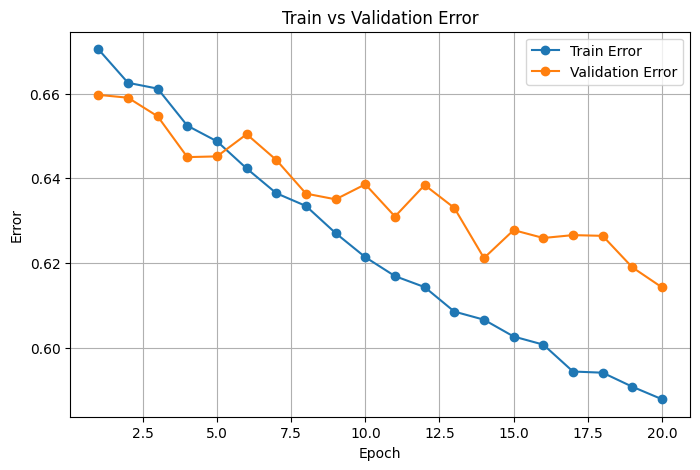

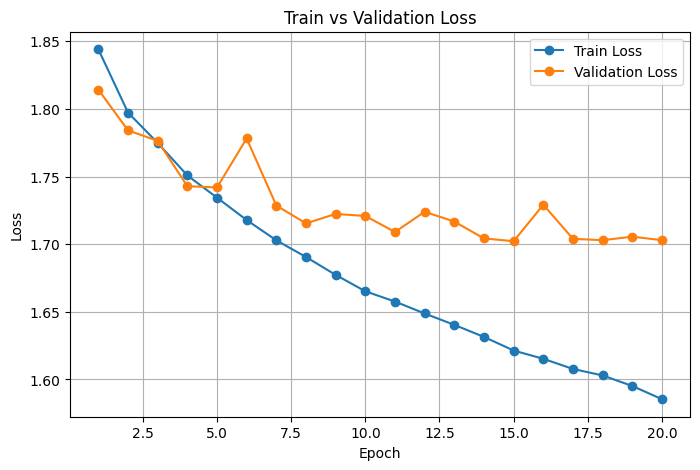

In [53]:
model = LargeANN(input_size=64*64, num_classes=num_classes).to(device)

model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, device, total_epochs=20, lr=1e-3
)

# Plot curves
plot_training_curves(train_accs, val_accs, train_losses, val_losses)

**13) Readjust the dataset for CNN so don't flatten the image into 1D vector, but 2D vector for CNN input**

In [54]:
#Dataset class FOR CNN
class FrameDataset(Dataset):
    def __init__(self, root_dir, label_map, transform=None):
        """
        Initialize the frame dataset.

        Args:
            root_dir: Root directory containing label folders
            label_map: Dictionary mapping label names to integer indices
            transform: Optional image transformations to apply
        """
        self.samples = [] # List to store (frame_path, label_index) tuples
        self.transform = transform

        # Iterate through each label directory
        for label in os.listdir(root_dir):
            label_path = os.path.join(root_dir, label)
            #Skip if not directory
            if not os.path.isdir(label_path):
                continue
            # Iterate through each video folder within the label directory
            for video in os.listdir(label_path):
                video_path = os.path.join(label_path, video)
                # Get all frame paths from this video
                frames = [os.path.join(video_path, f) for f in os.listdir(video_path)]
                # Add each frame as a separate sample with its corresponding label index
                for frame_path in frames:  # Each frame is treated independently
                    self.samples.append((frame_path, label_map[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # Get the frame path and label for this index
        frame_path, label = self.samples[idx]
        # Load image and convert to grayscale ('L' mode)
        image = Image.open(frame_path).convert('L')
        # Apply transformations such as resizing and normalize
        if self.transform:
            image = self.transform(image)
        return image, label

#Transforms: resize and normalize frames
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # resize to reduce input size
    transforms.ToTensor(),        # convert to [0,1] tensor
    transforms.Normalize((0.5,), (0.5,))  #normalize
])

In [55]:
#Create dataset
train_dataset = FrameDataset(os.path.join(DATA_DIR, "train"), label_map, transform)
val_dataset   = FrameDataset(os.path.join(DATA_DIR, "val"), label_map, transform)
test_dataset  = FrameDataset(os.path.join(DATA_DIR, "test"), label_map, transform)


#We have around 37000 videos with 15 frames/videos so around 555000 images total
#This create a huge dataset, so we went to limit it by subsample the dataset
def subsample_by_class(dataset, ratio=0.1):
    class_indices = {}
    for idx, (_, label) in enumerate(dataset.samples):  # no image loading
        class_indices.setdefault(label, []).append(idx)

    selected_indices = []
    for label, indices in class_indices.items():
        n_keep = max(1, int(len(indices) * ratio))
        sampled = random.sample(indices, n_keep)
        selected_indices.extend(sampled)

    np.random.shuffle(selected_indices)
    return Subset(dataset, selected_indices)

# Apply 10% per class
train_dataset = subsample_by_class(train_dataset, 0.1)
val_dataset   = subsample_by_class(val_dataset, 0.1)
test_dataset  = subsample_by_class(test_dataset, 0.1)



# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)


**14) 5th model: Simple CNN model (to achieve a Baseline Model of 50% since ANN was not good enough to learn from the dataset) - Use a 2D CNN**

In [69]:
# CNN Model to test as the ANN had accuracy values slightly lower than 39%
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_prob=0.3):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64*8*8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # conv + relu + pool + dropout in a single line per block
        x = self.dropout(self.pool(F.relu(self.conv1(x))))
        x = self.dropout(self.pool(F.relu(self.conv2(x))))
        x = self.dropout(self.pool(F.relu(self.conv3(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

**15) Train the Simple CNN model + Plot the Train/Validation Error & Loss**

In [70]:
# --- Training function ---
def train_cnn_model(train_loader, val_loader, device, num_classes, total_epochs=10, lr=1e-3, dropout_prob=0.3):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    print(f"Using device: {device}")

    for epoch in range(total_epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for images, labels_batch in train_loader:
            images, labels_batch = images.to(device), labels_batch.to(device, dtype=torch.long)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

        # Train metrics
        avg_train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Validation metrics
        val_acc, val_loss = evaluate(model, val_loader, device, criterion)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{total_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    print("Training complete.")

    # --- Plotting function ---
    epochs = np.arange(1, total_epochs+1)
    train_err = [1 - acc for acc in train_accs]
    val_err = [1 - acc for acc in val_accs]

    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_err, label="Train Error", marker='o')
    plt.plot(epochs, val_err, label="Validation Error", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.title("Train vs Validation Error")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_losses, label="Train Loss", marker='o')
    plt.plot(epochs, val_losses, label="Validation Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train vs Validation Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    return model, train_losses, val_losses, train_accs, val_accs

Using device: cuda
Epoch 1/10 | Train Loss: 1.7973 | Train Acc: 0.3449 | Val Loss: 1.7157 | Val Acc: 0.3923
Epoch 2/10 | Train Loss: 1.6513 | Train Acc: 0.4010 | Val Loss: 1.5904 | Val Acc: 0.4348
Epoch 3/10 | Train Loss: 1.5707 | Train Acc: 0.4312 | Val Loss: 1.4873 | Val Acc: 0.4607
Epoch 4/10 | Train Loss: 1.5204 | Train Acc: 0.4468 | Val Loss: 1.4586 | Val Acc: 0.4789
Epoch 5/10 | Train Loss: 1.4719 | Train Acc: 0.4611 | Val Loss: 1.4334 | Val Acc: 0.4784
Epoch 6/10 | Train Loss: 1.4398 | Train Acc: 0.4740 | Val Loss: 1.3938 | Val Acc: 0.4939
Epoch 7/10 | Train Loss: 1.4114 | Train Acc: 0.4861 | Val Loss: 1.3782 | Val Acc: 0.5054
Epoch 8/10 | Train Loss: 1.3930 | Train Acc: 0.4948 | Val Loss: 1.3519 | Val Acc: 0.5165
Epoch 9/10 | Train Loss: 1.3689 | Train Acc: 0.5009 | Val Loss: 1.3553 | Val Acc: 0.5106
Epoch 10/10 | Train Loss: 1.3532 | Train Acc: 0.5065 | Val Loss: 1.3413 | Val Acc: 0.5162
Training complete.


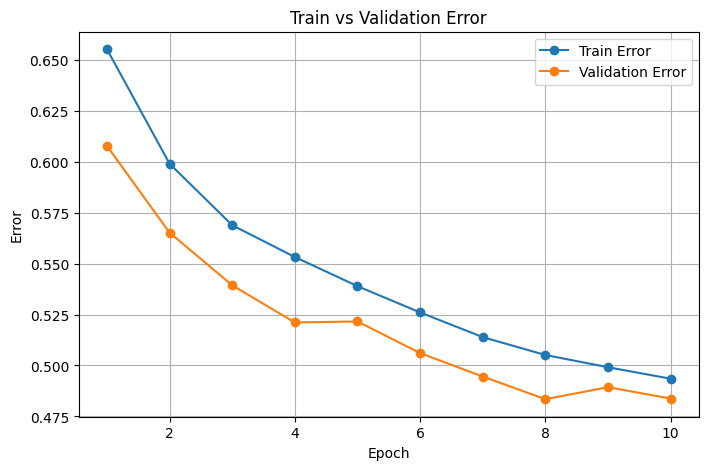

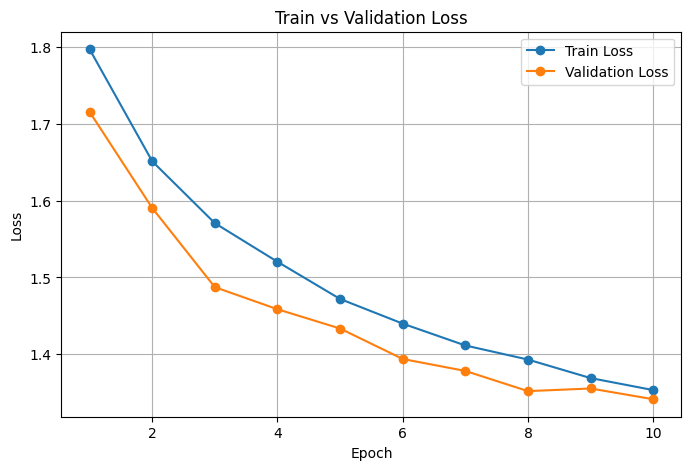

In [71]:
model = SimpleCNN(num_classes=num_classes, dropout_prob=0.3).to(device)

model, train_losses, val_losses, train_accs, val_accs = train_cnn_model(
    train_loader, val_loader, device, num_classes,
    total_epochs=10, lr=1e-3, dropout_prob=0.3
)

**16) Save and Test the Simple CNN Model using the evaluate function**

In [72]:
#Saved the trained model
torch.save(model.state_dict(), "simple_cnn_baseline.pth")

In [75]:
#Test the model
model_loaded = SimpleCNN(num_classes=num_classes, dropout_prob=0.3).to(device)

# Load the saved weights
model_loaded.load_state_dict(torch.load("simple_cnn_baseline.pth", map_location=device))

# Put the model in eval mode for testing
model_loaded.eval()

criterion = nn.CrossEntropyLoss()  # same as training

#Evaluate on test set
test_acc, test_loss = evaluate(model_loaded, test_loader, device, criterion)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Test Accuracy: 0.5228, Test Loss: 1.3329
